# Train model

In [ ]:
import sys
from pathlib import Path

# Kaggle:
# sys.path.insert(0, "/kaggle/input/datasets/gpla77/pro5-code")
# DATA_PATH = Path("/kaggle/input/datasets/gpla77/pro5-data/train.npz")
# CKPT_DIR  = Path("/kaggle/working/checkpoints")

# Local:
DATA_PATH = Path("data/train.npz")
CKPT_DIR  = Path("checkpoints")

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"Data   : {DATA_PATH}  (exists: {DATA_PATH.exists()})")

Device : cpu
Data   : data\train.npz  (exists: True)


# Dataset

In [3]:
from dataset import MotionDataset

dataset = MotionDataset(str(DATA_PATH))
seq, label = dataset[0]
print(f"Samples        : {len(dataset)}")
print(f"Sequence shape : {seq.shape}")   # [T, J, 3]
print(f"Num classes    : {int(dataset.labels.max()) + 1}")

Samples        : 1260
Sequence shape : torch.Size([48, 15, 3])
Num classes    : 2


# Train

In [4]:
from train import train

model = train(
    dataset        = dataset,
    # model
    d_model        = 256,
    nhead          = 4,
    num_layers     = 4,
    dropout        = 0.1,
    # diffusion
    timesteps      = 1000,
    beta_start     = 1e-4,
    beta_end       = 0.02,
    cfg_drop_prob  = 0.1,
    guidance_scale = 3.0,
    # training
    epochs         = 3,
    batch_size     = 32,
    lr             = 1e-4,
    optimizer      = "adamw",
    weight_decay   = 1e-4,
    scheduler      = "cosine",
    grad_clip      = 1.0,
    save_every     = 1,
    # qualitative eval
    eval_every     = 1,
    eval_samples   = 4,
    # misc
    device         = DEVICE,
    ckpt_dir       = str(CKPT_DIR),
    resume_from    = None,
    # Kaggle resume:
    # resume_from  = "/kaggle/input/YOUR_MODEL_DATASET/ckpt_e050.pt",
    seed           = 42,
    num_workers    = 0,   
)

d:\STUDIA SZI\Semestr 2\Sztuczna inteligencja w grafice komputerowej\Projekt\repo\AIComputerGraphics\project5-stick-animation\.pro5-sigk\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\STUDIA SZI\Semestr 2\Sztuczna inteligencja w grafice komputerowej\Projekt\repo\AIComputerGraphics\project5-stick-animation\modeling\model.py:55: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


MotionDenoiser  params: 3,458,349  |  device: cpu
dataset: 1260  classes: 2


Epoch 001/3  loss=1.9785  lr=1.00e-04  |  samples → samples_e001.pt


Epoch 002/3  loss=0.8934  lr=7.52e-05  |  samples → samples_e002.pt


Epoch 003/3  loss=0.6997  lr=2.58e-05  |  samples → samples_e003.pt

Done → checkpoints\final_model.pt


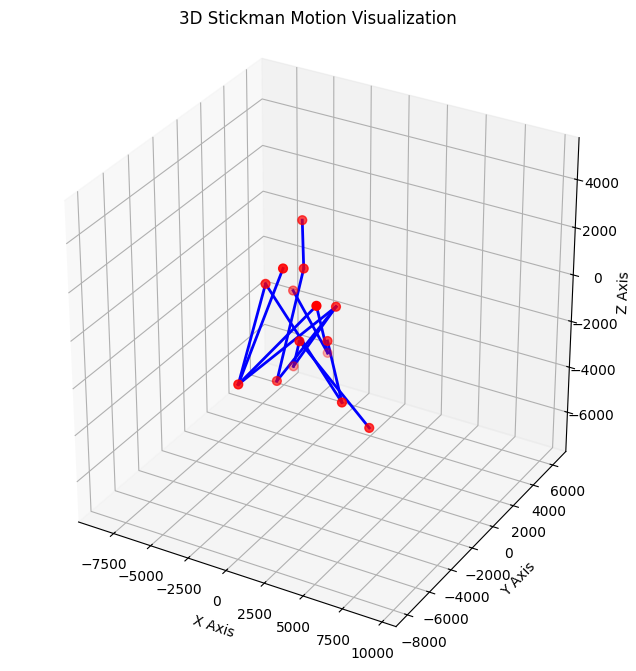

saved → checkpoints\samples\gifs\samples_e001\walk_s1.gif


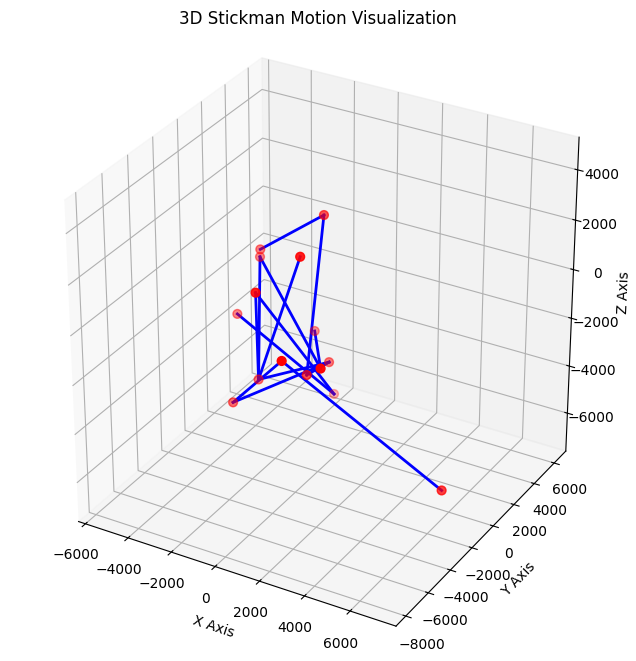

saved → checkpoints\samples\gifs\samples_e001\walk_s2.gif


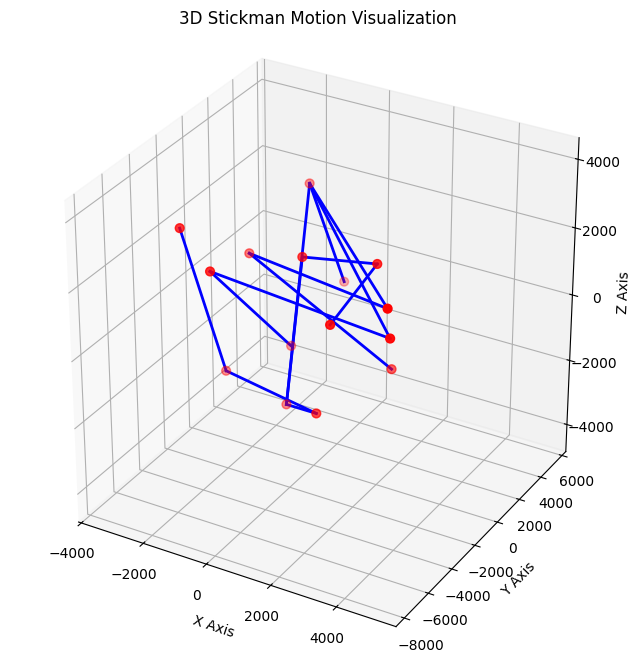

saved → checkpoints\samples\gifs\samples_e001\walk_s3.gif


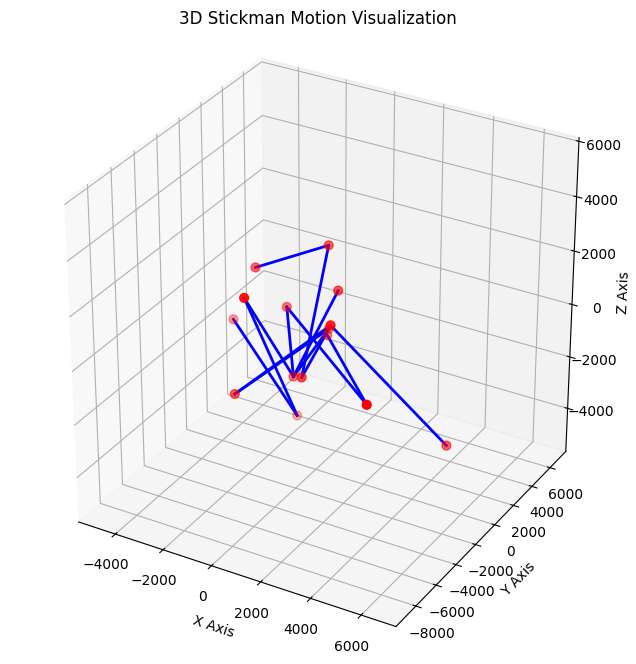

saved → checkpoints\samples\gifs\samples_e001\walk_s4.gif


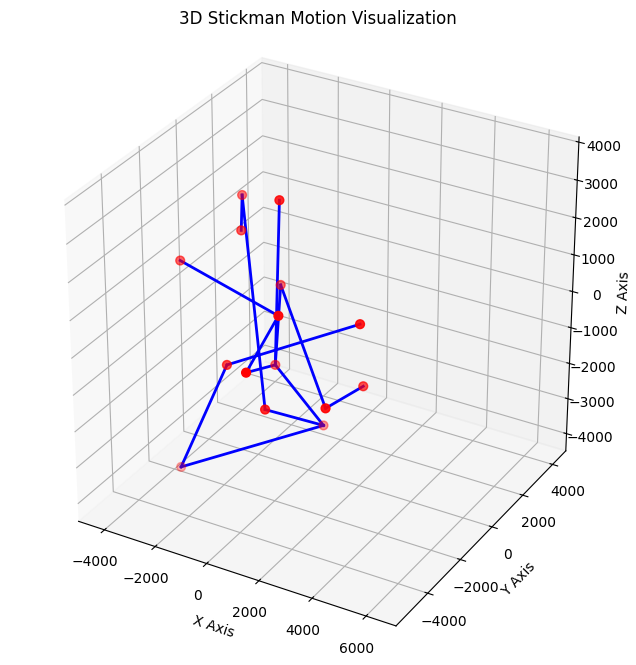

saved → checkpoints\samples\gifs\samples_e001\jump_s1.gif


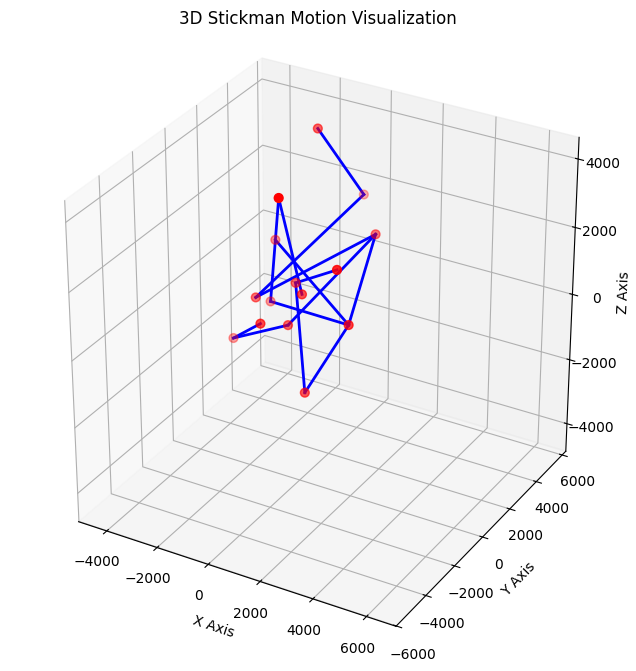

saved → checkpoints\samples\gifs\samples_e001\jump_s2.gif


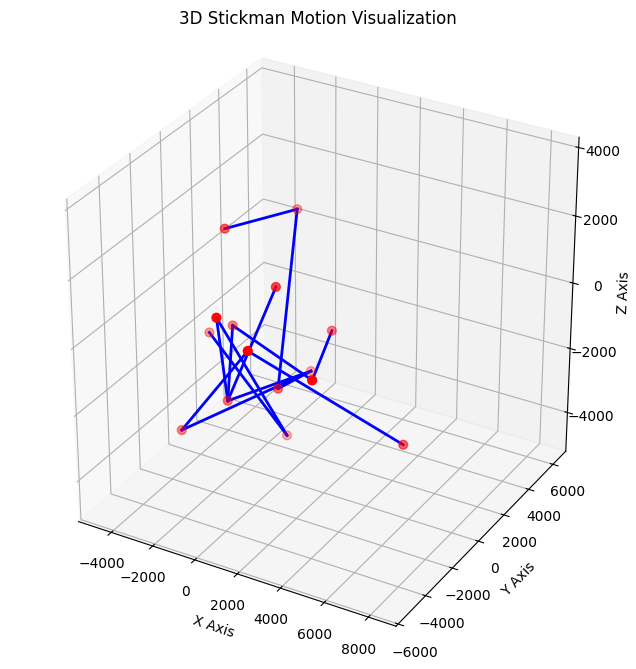

saved → checkpoints\samples\gifs\samples_e001\jump_s3.gif


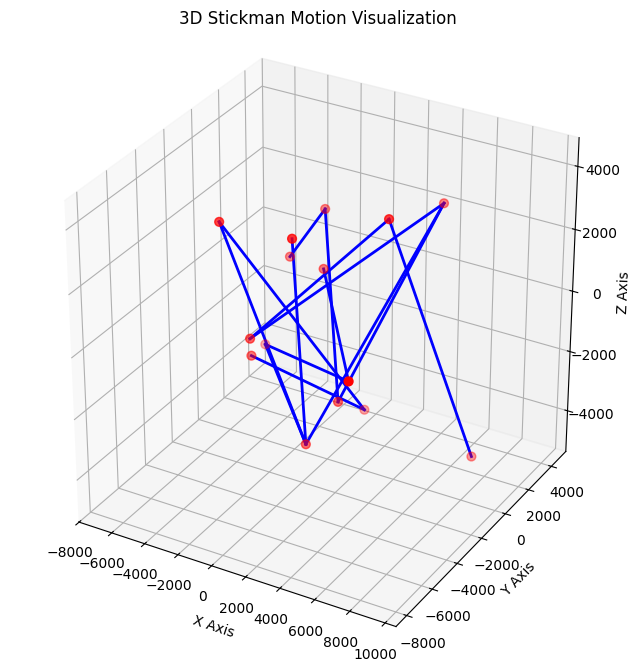

saved → checkpoints\samples\gifs\samples_e001\jump_s4.gif


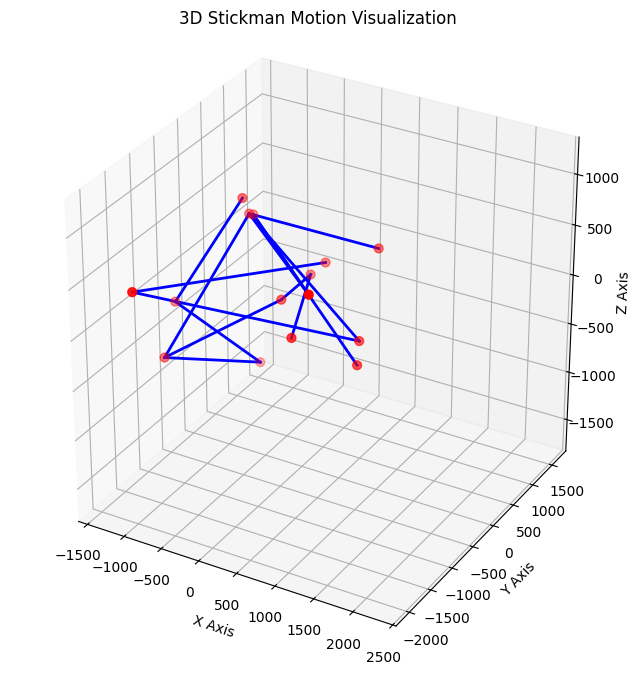

saved → checkpoints\samples\gifs\samples_e002\walk_s1.gif


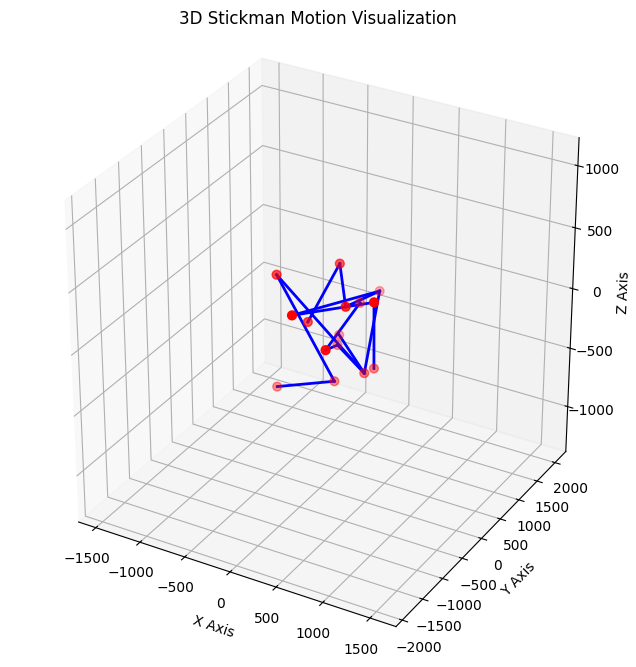

saved → checkpoints\samples\gifs\samples_e002\walk_s2.gif


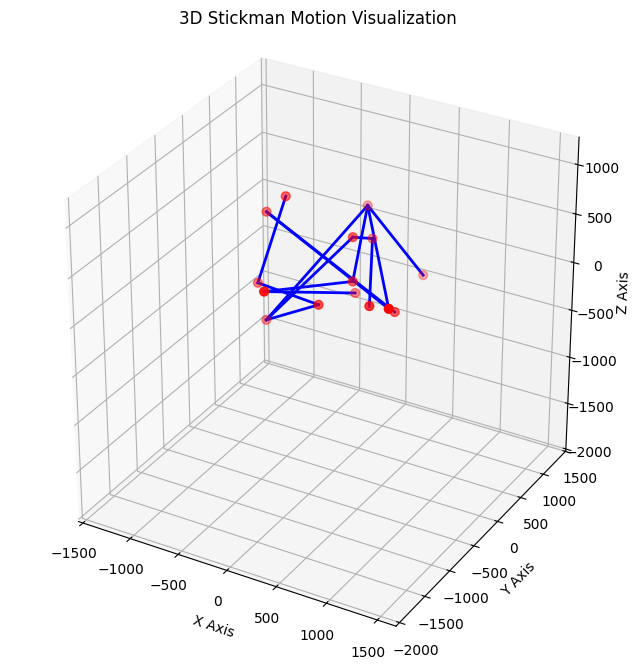

saved → checkpoints\samples\gifs\samples_e002\walk_s3.gif


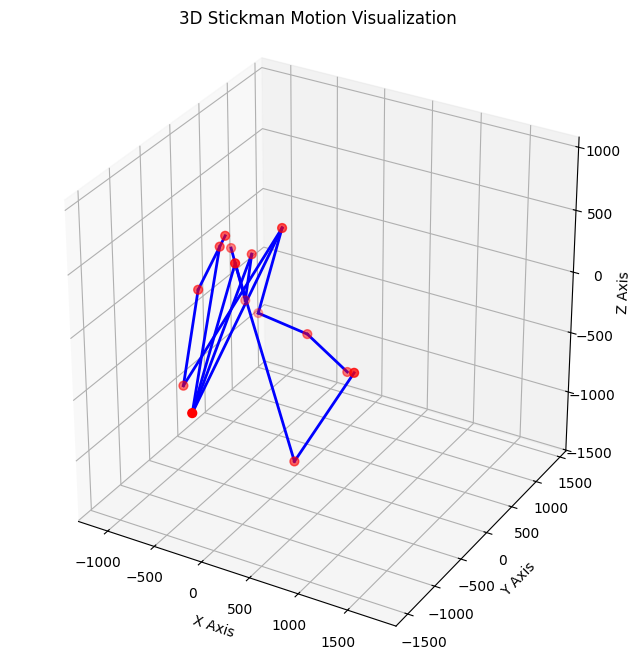

saved → checkpoints\samples\gifs\samples_e002\walk_s4.gif


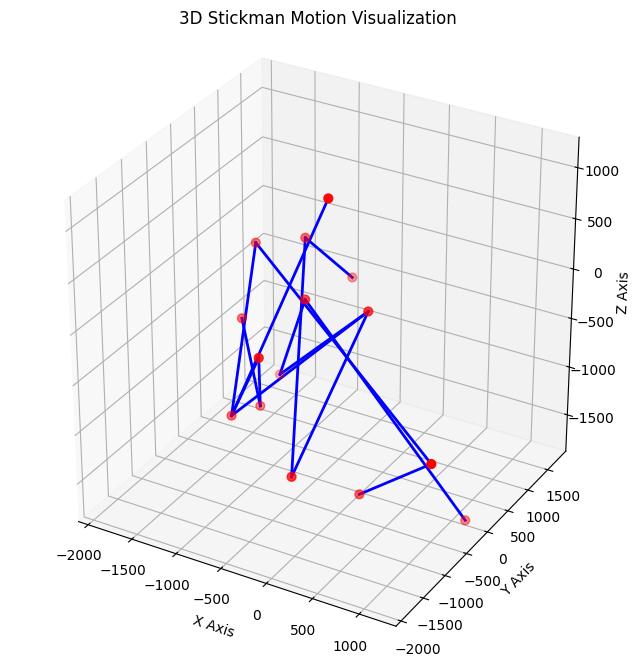

saved → checkpoints\samples\gifs\samples_e002\jump_s1.gif


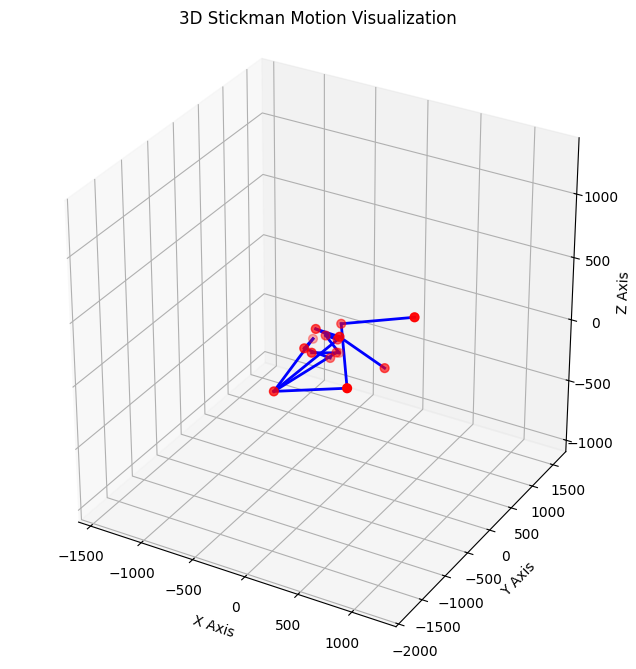

saved → checkpoints\samples\gifs\samples_e002\jump_s2.gif


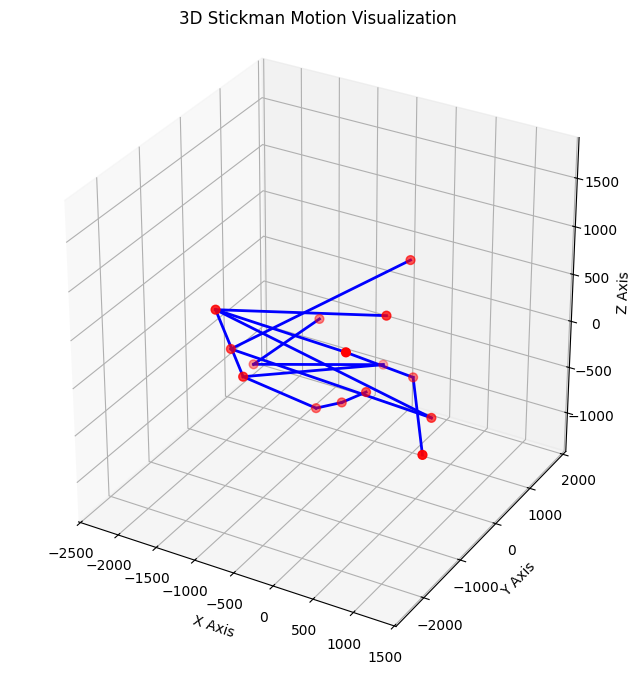

saved → checkpoints\samples\gifs\samples_e002\jump_s3.gif


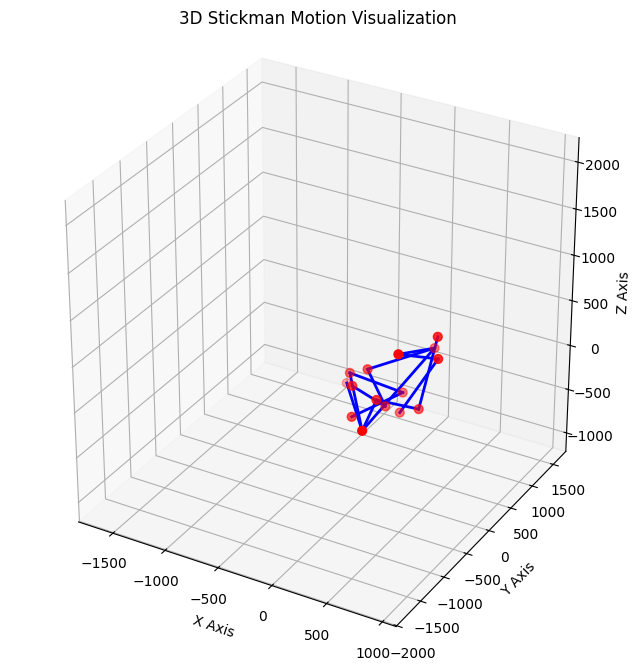

saved → checkpoints\samples\gifs\samples_e002\jump_s4.gif


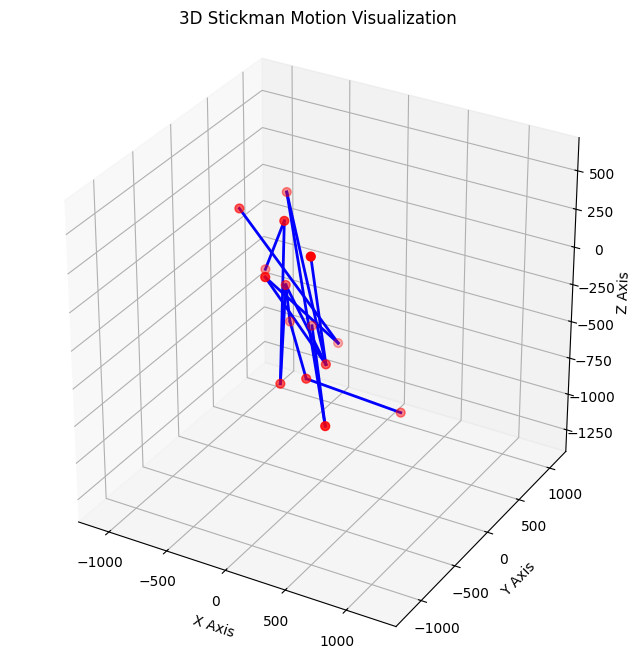

saved → checkpoints\samples\gifs\samples_e003\walk_s1.gif


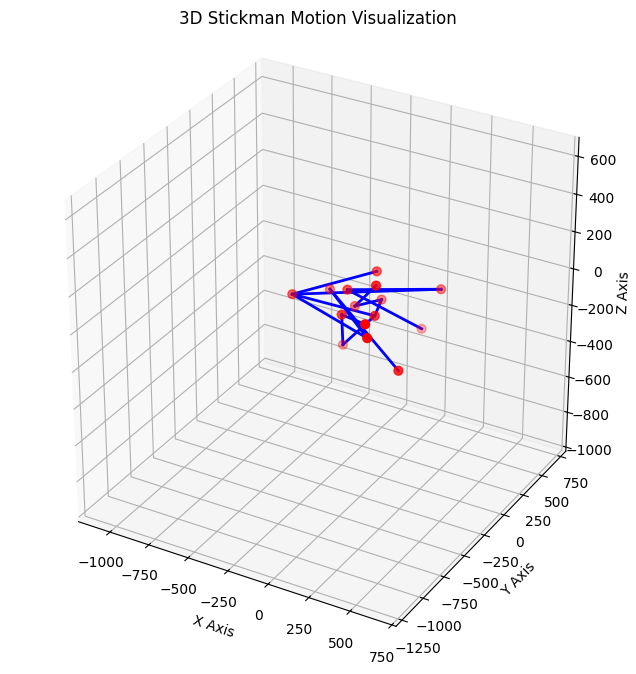

saved → checkpoints\samples\gifs\samples_e003\walk_s2.gif


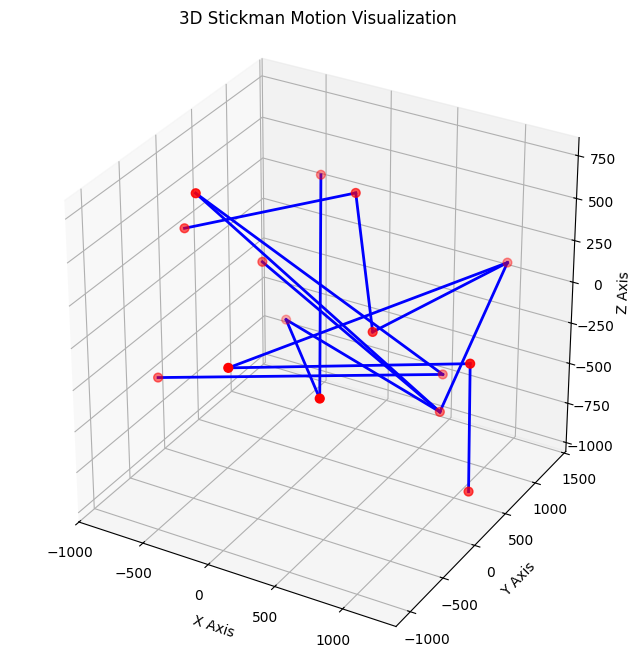

saved → checkpoints\samples\gifs\samples_e003\walk_s3.gif


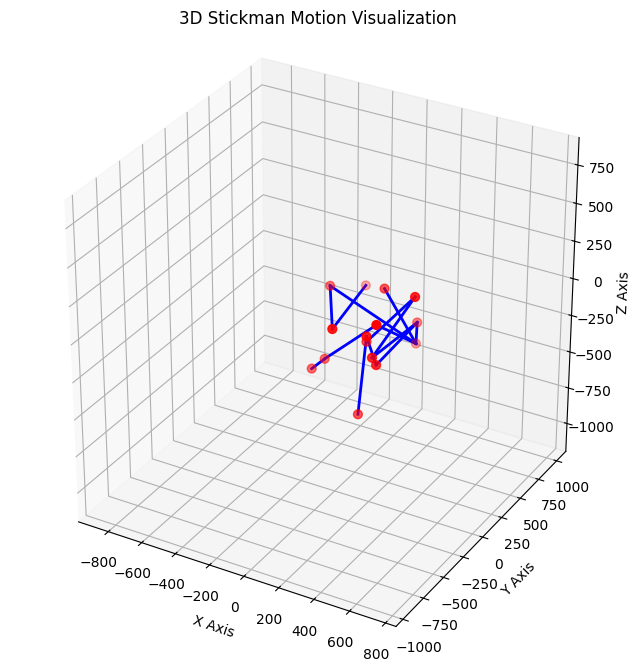

saved → checkpoints\samples\gifs\samples_e003\walk_s4.gif


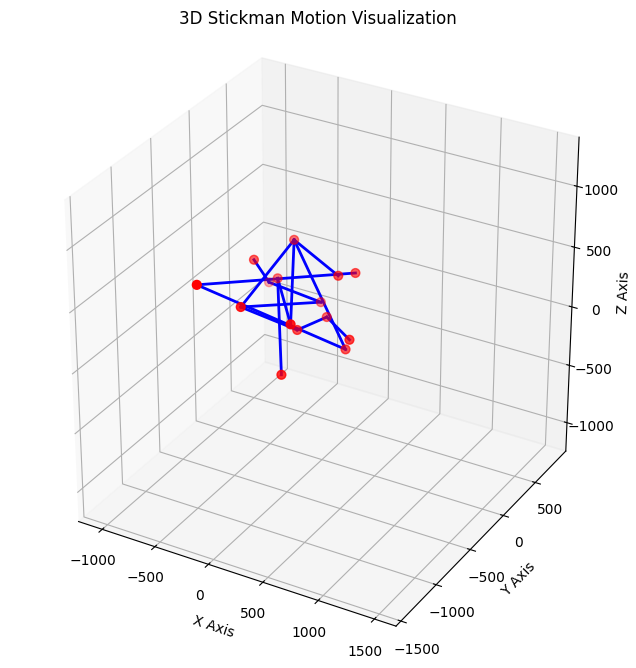

saved → checkpoints\samples\gifs\samples_e003\jump_s1.gif


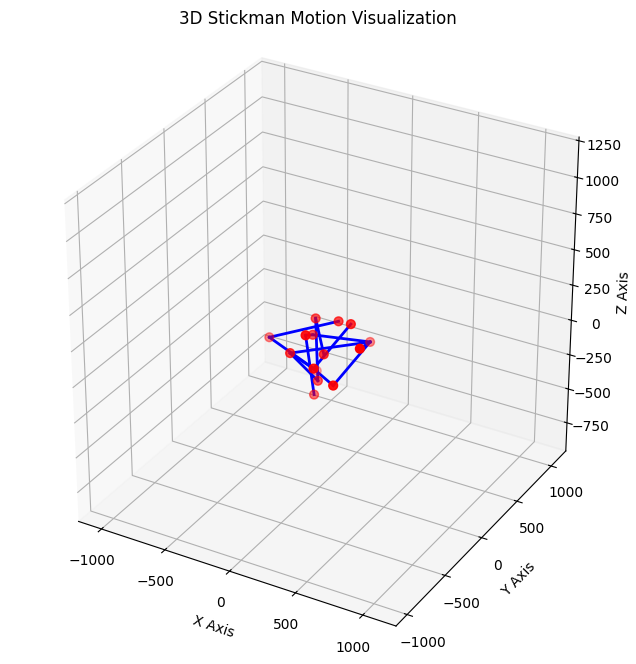

saved → checkpoints\samples\gifs\samples_e003\jump_s2.gif


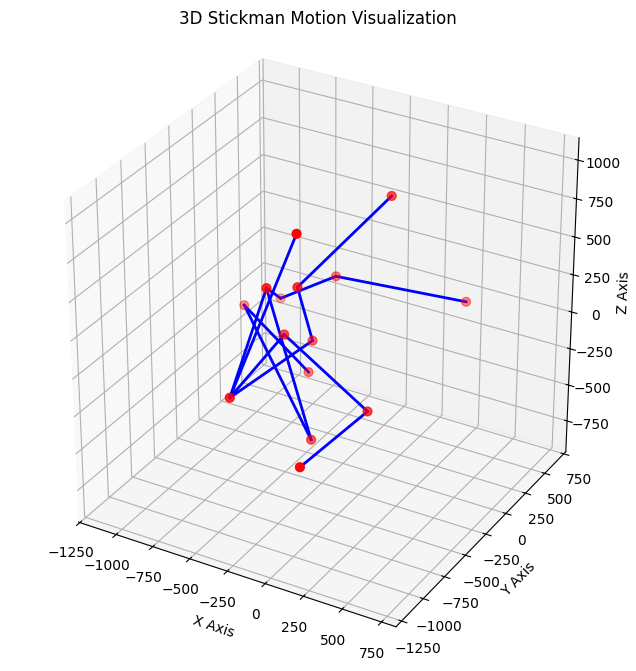

saved → checkpoints\samples\gifs\samples_e003\jump_s3.gif


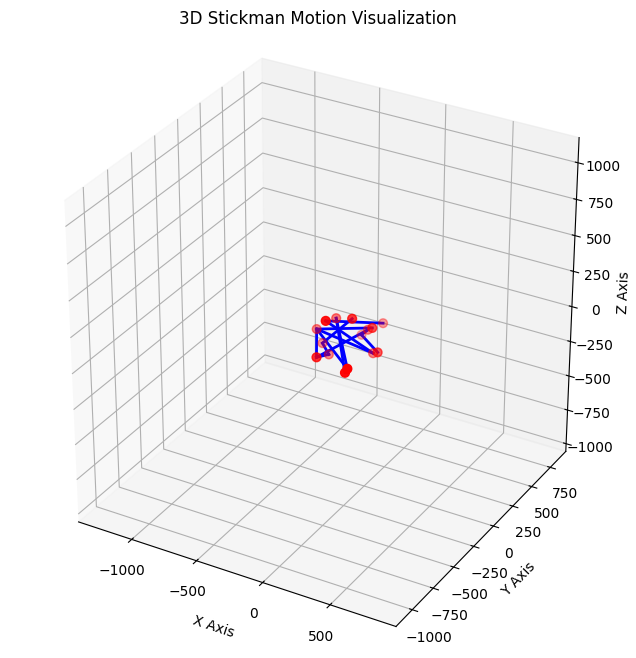

saved → checkpoints\samples\gifs\samples_e003\jump_s4.gif


In [6]:
from pathlib import Path
from sample import visualize_training_samples

for pt_file in sorted(Path("checkpoints/samples").glob("samples_e*.pt")):
    visualize_training_samples(
        samples_pt = str(pt_file),
        save_dir   = f"checkpoints/samples/gifs/{pt_file.stem}",
        fps        = 24,
    )